# Shai Gilgeous-Alexander — free throws, regular season vs playoffs

Does SGA get to the line differently once the playoffs start? `FTM` is free throws
made per game; `FTA` is attempts.

Free throws made is a **count** — a non-negative integer with heavy ties (roughly 15-19
distinct values across ~70 games). So this notebook treats it as discrete throughout:
probability mass at each integer rather than binned bars, and a negative binomial rather
than a continuous fit.

Data comes from NBA.com via `nba_api`, cached under `data/cache/`, one file per
(player, season, season type). Season convention: the ending year — `2026` = the 2025-26
season, the most recent completed one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nba_analysis import compare_models, fit_nbinom, get_game_logs, survival, thinning_check
from nba_analysis.data import normalize_season

sns.set_theme(style="whitegrid")

PLAYER = "Shai Gilgeous-Alexander"

# Categorical slots from the reference palette (light surface).
SEASON_TYPE_COLORS = {"Regular Season": "#2a78d6", "Playoffs": "#008300"}
SEASON_COLORS = {"2023-24": "#2a78d6", "2024-25": "#008300", "2025-26": "#e87ba4"}
FIT_INK = "#52514e"      # model overlays are annotation, not a data series
LABEL_INK = "#52514e"

## Which seasons can actually be compared?

Pooling every regular-season game against every playoff game would be misleading. SGA has
only played playoff games in five seasons, and the two early ones came when he was a
much lower-usage player — 1.9 FTM per game in 2018-19 against roughly 8 today. Pooling
would blend that career growth into anything we then called a "playoff effect".

In [2]:
LATEST_SEASON = 2026

rows = [
    {
        "SEASON": normalize_season(season),
        "SEASON_TYPE": season_type,
        "GAMES": len(get_game_logs(PLAYER, season, season_type=season_type)),
    }
    for season in range(2019, LATEST_SEASON + 1)
    for season_type in SEASON_TYPE_COLORS
]

pd.DataFrame(rows).pivot(index="SEASON", columns="SEASON_TYPE", values="GAMES")

SEASON_TYPE,Playoffs,Regular Season
SEASON,,
2018-19,6,82
2019-20,7,70
2020-21,0,35
2021-22,0,56
2022-23,0,68
2023-24,10,75
2024-25,23,76
2025-26,15,68


So the comparison set is his three deep-run seasons — **2023-24, 2024-25 and 2025-26**:
same player, same role, 219 regular-season games against 48 playoff games.

In [3]:
SEASONS = [2024, 2025, 2026]
SEASON_LABELS = [normalize_season(s) for s in SEASONS]

## The distributions, as probability mass at each integer

`FTM` only ever takes integer values, so rather than binning it we plot P(FTM = k) at every k.
Points are drawn unconnected on purpose: nothing exists between k=7 and k=8, and a connecting
line there would draw a shape the data doesn't have.

Each series is normalized within itself, so heights are the share of that season type's games
— otherwise the 48 playoff games would vanish under 219 regular-season ones.

**Read the playoff series with care.** At n=48, one game is worth 2.1 percentage points, so the
green points bounce by 1-3 games at a time and most of that motion is sampling noise rather
than shape. This is precisely the weakness the survival function below fixes: a PMF spends its
whole sample on one integer at a time, while S(k) accumulates every observation to the right.

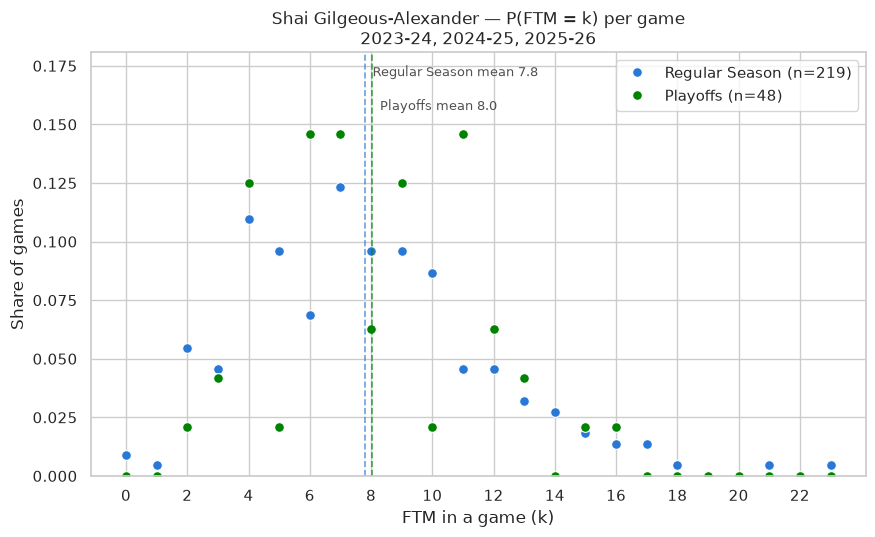

In [4]:
def pmf_points(player, seasons, stat="FTM", ax=None):
    """Plot P(stat = k) at each integer k, regular season vs playoffs.

    Each season type is normalized within itself, so the y value is the share of
    that season type's games. Markers are left unconnected because the support is
    the integers — there is no value between k and k+1 to interpolate. Returns the Axes.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5.5))

    samples = {
        st: get_game_logs(player, seasons, season_type=st)[stat].to_numpy()
        for st in SEASON_TYPE_COLORS
    }
    ks = np.arange(0, max(v.max() for v in samples.values()) + 1)

    for season_type, color in SEASON_TYPE_COLORS.items():
        values = samples[season_type]
        pmf = np.array([(values == k).mean() for k in ks])
        ax.plot(
            ks, pmf,
            marker="o", markersize=7, linewidth=0, color=color,
            markeredgecolor="white", markeredgewidth=0.8,
            label=f"{season_type} (n={len(values)})",
        )
        ax.axvline(values.mean(), color=color, linestyle="--", linewidth=1.2, alpha=0.7)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    top = ax.get_ylim()[1]
    for i, (season_type, color) in enumerate(SEASON_TYPE_COLORS.items()):
        mean = samples[season_type].mean()
        ax.text(mean + 0.25, top * (0.97 - 0.08 * i), f"{season_type} mean {mean:.1f}",
                color=LABEL_INK, fontsize=9, va="top")

    ax.set_xticks(ks[::2])
    ax.set_title(f"{player} — P({stat} = k) per game\n{', '.join(normalize_season(s) for s in seasons)}")
    ax.set_xlabel(f"{stat} in a game (k)")
    ax.set_ylabel("Share of games")
    ax.legend(loc="upper right", frameon=True)
    return ax


pmf_points(PLAYER, SEASONS, stat="FTM")
plt.show()

## Attempts as well as makes

Makes mix two things — how often he gets to the line, and whether he hits them once there.
`FTA` isolates the first.

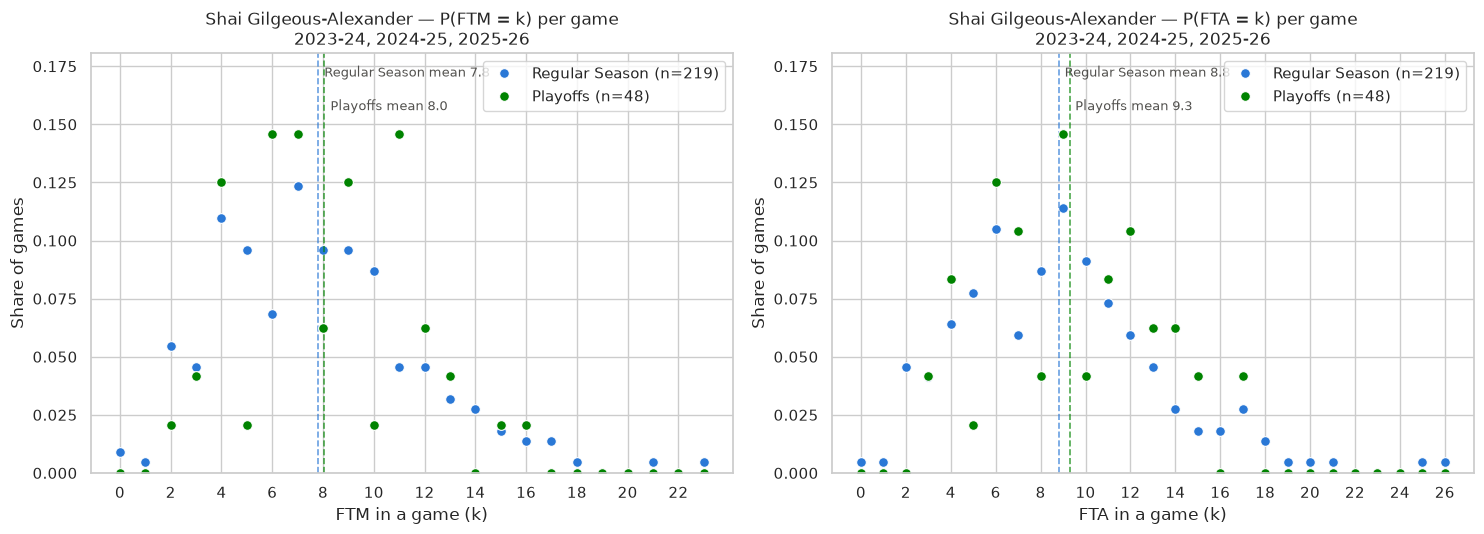

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
pmf_points(PLAYER, SEASONS, stat="FTM", ax=axes[0])
pmf_points(PLAYER, SEASONS, stat="FTA", ax=axes[1])
plt.tight_layout()
plt.show()

## Does the playoff gap hold up season by season?

Pooling three seasons can manufacture an effect that no individual season shows, so it's
worth splitting the difference back out.

In [6]:
per_season = pd.DataFrame(
    [
        {
            "SEASON": normalize_season(season),
            "RS_FTM": get_game_logs(PLAYER, season).FTM.mean(),
            "PO_FTM": get_game_logs(PLAYER, season, season_type="Playoffs").FTM.mean(),
            "PO_GAMES": len(get_game_logs(PLAYER, season, season_type="Playoffs")),
        }
        for season in SEASONS
    ]
).set_index("SEASON")

per_season["DIFF"] = per_season.PO_FTM - per_season.RS_FTM
per_season.round(2)

,RS_FTM,PO_FTM,PO_GAMES,DIFF
SEASON,,,,
2023-24,7.56,6.40,10,-1.16
2024-25,7.91,8.26,23,0.35
2025-26,7.94,8.80,15,0.86


It doesn't. The playoff gap runs **-1.2, +0.4, +0.9** across the three seasons — it flips
sign, and each estimate rests on 10-23 playoff games. The pooled "playoff edge" of +0.2 sits
well inside that churn, so it reads as noise rather than a finding.

## Survival functions by season (regular season)

The survival function is S(k) = P(FTM > k) — the share of games in which he made *more than*
k free throws. It's the complement of the empirical CDF, and it's a better tail instrument
than a histogram: no binning choice, and every observation contributes to every point to its
left.

The y axis is log-scaled, which turns tail shape into slope. An exponential-ish tail falls
roughly as a straight line; a genuinely fat (power-law) tail visibly bends upward, staying
high far longer than a straight line would.

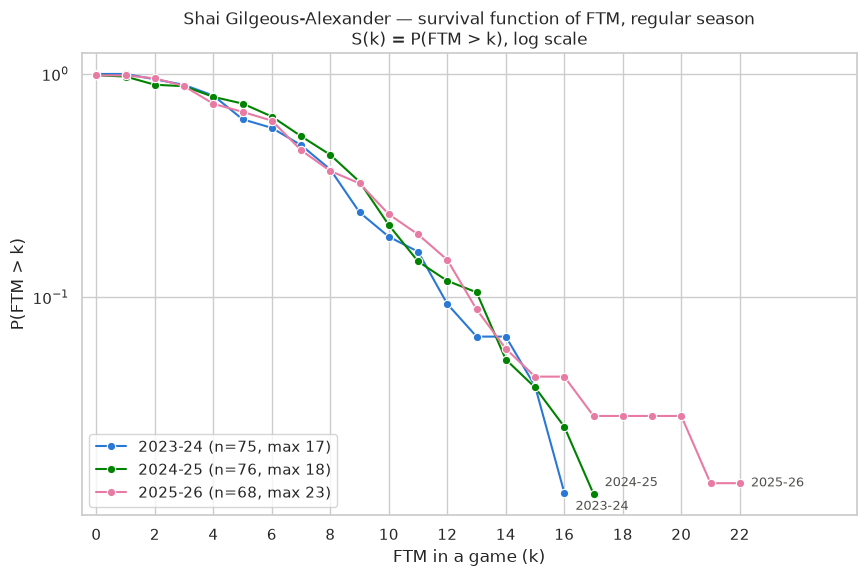

In [7]:
def survival_by_season(player, seasons, stat="FTM", ax=None):
    """Overlay one empirical survival curve per regular season, on a log y axis."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    samples = {normalize_season(s): get_game_logs(player, s)[stat].to_numpy() for s in seasons}
    kmax = max(v.max() for v in samples.values())
    ks = np.arange(0, kmax + 1)

    # The curves nearly coincide and all end in the same corner, so stagger the
    # end labels vertically to keep them off each other.
    label_offsets = [(8, -10), (8, 8), (8, 0)]

    for i, (label, values) in enumerate(samples.items()):
        s = survival(values, ks)
        visible = s > 0  # log axis cannot show S(k)=0 beyond the sample max
        ax.plot(
            ks[visible], s[visible],
            marker="o", markersize=6, linewidth=1.5, color=SEASON_COLORS[label],
            markeredgecolor="white", markeredgewidth=0.8,
            label=f"{label} (n={len(values)}, max {values.max()})",
        )
        # Direct label at the tail end of each curve, so identity is never color-alone.
        last = np.flatnonzero(visible)[-1]
        ax.annotate(
            label, (ks[last], s[last]), xytext=label_offsets[i % len(label_offsets)],
            textcoords="offset points", color=LABEL_INK, fontsize=9, va="center",
        )

    ax.set_yscale("log")
    ax.set_xticks(ks[::2])
    ax.set_xlim(-0.5, kmax + 3)
    ax.set_title(f"{player} — survival function of {stat}, regular season\nS(k) = P({stat} > k), log scale")
    ax.set_xlabel(f"{stat} in a game (k)")
    ax.set_ylabel(f"P({stat} > k)")
    ax.legend(loc="lower left", frameon=True)
    return ax


survival_by_season(PLAYER, SEASONS, stat="FTM")
plt.show()

The three seasons trace nearly the same curve, and all three fall off in a roughly straight
line on the log axis — that is an **exponential-class tail, not a fat one**. 2025-26 carries
slightly further right (a 23-FT game), but that's one game.

## Fitting a negative binomial

The negative binomial is the natural model here, for a structural reason rather than a
curve-fitting one. FTM is a *binomial thinning* of FTA — each attempt independently converts
with probability p ≈ 0.88 — and the negative binomial is **closed under binomial thinning**:
if FTA ~ NB(r, q) then FTM ~ NB(r, q′) with the *same* r. That's a testable prediction, and
the fitted r values below should come out close.

In [8]:
rs_logs = get_game_logs(PLAYER, SEASONS)
pd.Series(thinning_check(rs_logs.FTA.to_numpy(), rs_logs.FTM.to_numpy())).round(3)

r_attempts    7.330
r_makes       7.896
ratio         1.077
p_attempts    0.454
p_makes       0.503
dtype: float64

r = 7.33 for attempts against 7.90 for makes — close, as thinning predicts. (They're two
noisy MLEs from 219 games, so exact equality was never on the table; the point is that the
dispersion parameter survives the thinning roughly intact.)

Now the fit itself, one panel per season plus the pooled set. The negative binomial fit is
drawn as a gray dashed line in every panel — it's a model overlay, not a fourth season, so it
deliberately doesn't take a season color.

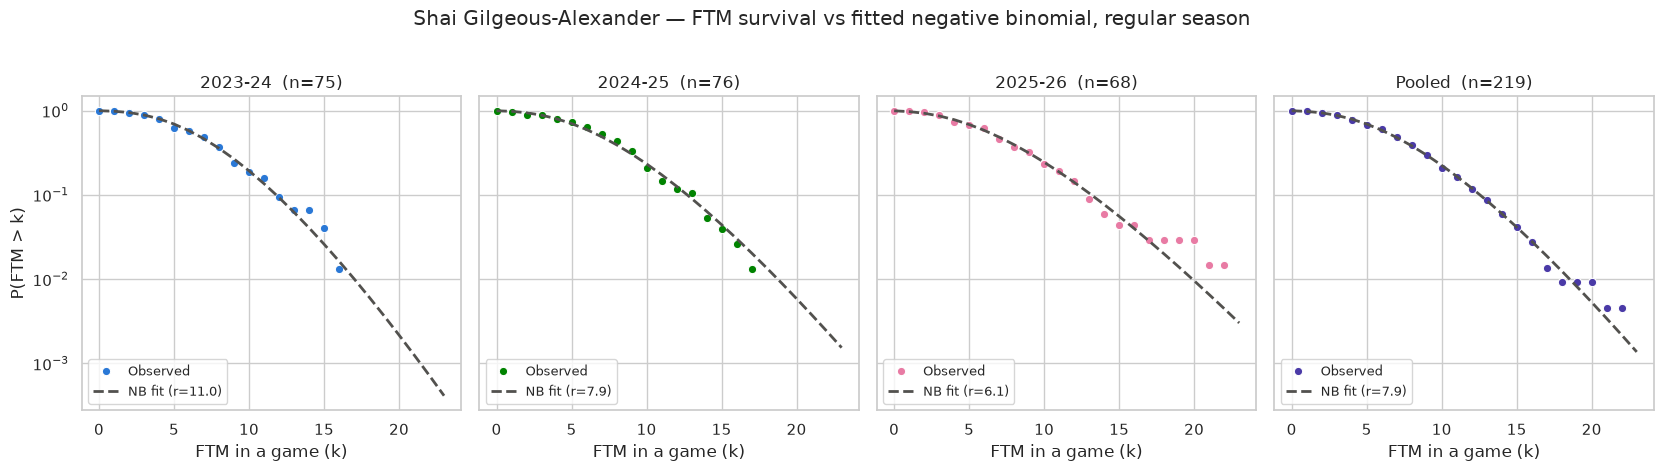

In [9]:
def survival_with_nb_fit(player, seasons, stat="FTM"):
    """Small multiples: empirical survival + fitted NB survival, per season and pooled."""
    panels = [(normalize_season(s), get_game_logs(player, s)[stat].to_numpy()) for s in seasons]
    pooled = np.concatenate([v for _, v in panels])
    panels.append(("Pooled", pooled))

    # Shared axes on both dimensions: the panels are meant to be read against
    # each other, which a per-panel x range would quietly undermine.
    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.6), sharey=True, sharex=True)
    kmax = pooled.max()

    for ax, (label, values) in zip(axes, panels):
        ks = np.arange(0, kmax + 1)
        emp = survival(values, ks)
        fit = fit_nbinom(values)
        color = SEASON_COLORS.get(label, "#4a3aa7")

        ax.plot(ks[emp > 0], emp[emp > 0], marker="o", markersize=6, linewidth=0,
                color=color, markeredgecolor="white", markeredgewidth=0.8, label="Observed")
        ax.plot(ks, fit.sf(ks), linestyle="--", linewidth=2,
                color=FIT_INK, label=f"NB fit (r={fit.r:.1f})")

        ax.set_yscale("log")
        ax.set_title(f"{label}  (n={len(values)})")
        ax.set_xlabel(f"{stat} in a game (k)")
        ax.legend(loc="lower left", frameon=True, fontsize=9)

    axes[0].set_ylabel(f"P({stat} > k)")
    fig.suptitle(f"{player} — {stat} survival vs fitted negative binomial, regular season", y=1.02)
    plt.tight_layout()
    return fig


survival_with_nb_fit(PLAYER, SEASONS, stat="FTM")
plt.show()

The dashed NB curve tracks the observed points closely through the **body** of all four
panels. The far tail is where it strains: in 2025-26 and in the pooled panel, the last few
points sit visibly *above* the fitted line, so the NB slightly under-predicts games above
roughly 17 FTM. Worth being precise about how weak that evidence is — it's 2-3 games out of
219, and the 2025-26 panel's low r (6.1 against 7.9 pooled) is largely that one 23-FT game
dragging the fit. But the direction is the one you'd expect if something marginally
heavier-tailed than NB were at work, so it's the honest place to look if this ever gets
revisited with more seasons.

## Is the negative binomial actually the best of the candidates?

A visual fit is suggestive, not decisive. Comparing by AIC puts the candidates on the same
footing — all three are scored on the same discrete support, which means the lognormal has to
be **discretized** (P(X=k) = F(k+½) − F(k−½)) rather than evaluated as a density. That
discretization also fixes the reason a raw lognormal can't be fit here at all: it assigns
positive probability to zero, where log(0) is undefined.

In [10]:
rows = []
for season in SEASONS + ["pooled"]:
    if season == "pooled":
        label, x = "pooled", get_game_logs(PLAYER, SEASONS).FTM.to_numpy()
    else:
        label, x = normalize_season(season), get_game_logs(PLAYER, season).FTM.to_numpy()

    rows.append({
        "SEASON": label,
        "n": len(x),
        "var/mean": x.var(ddof=1) / x.mean(),
        **compare_models(x),
    })

model_aic = pd.DataFrame(rows).set_index("SEASON")
model_aic["best"] = model_aic[["NegBinom", "discLogNorm", "Poisson"]].idxmin(axis=1)
model_aic.round(1)

,n,var/mean,NegBinom,discLogNorm,Poisson,best
SEASON,,,,,,
2023-24,75,1.7,400.6,402.6,410.8,NegBinom
2024-25,76,1.9,424.4,449.1,442.4,NegBinom
2025-26,68,2.4,385.4,397.6,415.1,NegBinom
pooled,219,2.0,1204.3,1246.0,1265.2,NegBinom


The negative binomial wins every season and the pooled set — by 42 AIC units over the
discretized lognormal pooled, and 61 over Poisson, both decisive margins. Poisson loses for a
visible reason: `var/mean` sits near 2 in every season, where Poisson requires it to be 1.
That overdispersion is exactly what the NB's second parameter buys.

## Summary

In [11]:
logs = pd.concat(
    [get_game_logs(PLAYER, SEASONS, season_type=st) for st in SEASON_TYPE_COLORS],
    ignore_index=True,
)

summary = (
    logs.groupby("SEASON_TYPE")[["FTM", "FTA"]]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)
summary[("FT%", "made/attempted")] = (
    logs.groupby("SEASON_TYPE")
    .apply(lambda g: g.FTM.sum() / g.FTA.sum(), include_groups=False)
    .round(3)
)
summary

FTM                       FTA                      \
               count  mean   std min max count  mean   std min max   
SEASON_TYPE                                                          
Playoffs          48  8.04  3.29   2  16    48  9.29  3.71   3  17   
Regular Season   219  7.80  3.93   0  23   219  8.82  4.41   0  26   

                          FT%  
               made/attempted  
SEASON_TYPE                    
Playoffs                0.865  
Regular Season          0.884

**What the data says**, across 2023-24, 2024-25 and 2025-26:

- **Playoff volume is essentially flat.** 7.8 made free throws per game in the regular season
  against 8.0 in the playoffs — a gap that doesn't survive the per-season split, where it
  flips sign.
- **He gets to the line a bit more in the playoffs** (9.3 attempts against 8.8) but
  **converts a bit worse** (86.5% vs 88.4%), and the two roughly cancel into the same makes.
- **The spread tightens, and this is the sturdiest difference here.** Standard deviation drops
  from 3.93 to 3.29 and the regular season's zero-trip games disappear. It has a mechanical
  cause: playoff games are close games with tight rotations, so the rest games and blowouts
  that produce the low tail aren't in the sample at all.
- **The distribution is negative binomial, not fat-tailed.** Pooled FTM has skewness 0.72 and
  excess kurtosis 0.73 — mild. The survival curves fall off in a straight line on a log axis,
  and NB beats both alternatives on AIC in every season.

Caveats worth keeping: 48 playoff games is a small sample, and playoff games aren't a random
draw — better defenses, tighter rotations, no back-to-backs. This describes the difference; it
doesn't isolate a cause. The AIC comparison also ranks these three candidates against each
other; it does not establish that the winner is *correct*, only that it's the best of the
three offered.